# Классификация: линейные модели и нелинейные границы

Практикум состоит из трёх упражнений:

1. **Устойчивая логистическая регрессия:** реализовать потерю и градиент, проверить их численно.
2. **Accuracy = 1:** исследовать веса и потери на разделимой выборке, сравнить с SVM.
3. **XOR:** обучить разные классификаторы, сравнить границы решений и подобрать сложность нелинейной модели.

Все данные синтетические и генерируются локально. Упражнение 2 использует реализацию из упражнения 1; упражнение 3 работает независимо. Ячейки **ВАШ КОД** предназначены для заполнения. Генераторы, визуализации и проверки уже готовы. После каждого эксперимента сформулируйте объяснение результата.

Теория вынесена отдельно: [конспект](2.%20Classification%20%E2%80%94%20theory%20notes.ipynb) · [подробное изложение](2.%20Classification%20%E2%80%94%20theory%20detailed.ipynb).

## 0. Подготовка
Нужны NumPy, SciPy, pandas, Matplotlib и scikit-learn из среды курса. Интернет, GPU и дополнительные датасеты не используются.

Графики — обычные изображения в выводе ячеек. Чтобы изменить эксперимент, отредактируйте параметры и выполните соответствующие ячейки ещё раз. Вспомогательный код можно свернуть.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.metrics import accuracy_score, roc_auc_score
from IPython.display import display

SEED = 42
BLUE, ORANGE, GREEN, RED = '#2563eb', '#ea580c', '#059669', '#dc2626'
plt.rcParams.update({'figure.figsize':(10,4), 'font.size':11,
                     'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.2})

def augment(X):
    return np.c_[X, np.ones(len(X))]  # сдвиг всегда последний

def class_scatter(ax, X, y):
    for label, color in [(0,BLUE),(1,ORANGE)]:
        ax.scatter(X[y==label,0],X[y==label,1],s=22,c=color,alpha=.7,label=f'Класс {label}')
    ax.set(xlabel='x₁',ylabel='x₂')

def boundary(ax, theta, **kwargs):
    # A @ theta = 0: работает и для почти вертикальной границы.
    xx,yy=np.meshgrid(np.linspace(-3,3,120),np.linspace(-3,3,120))
    z=theta[0]*xx+theta[1]*yy+theta[2]
    ax.contour(xx,yy,z,levels=[0],**kwargs)

print('Среда готова')
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D


Среда готова


## 1. Логистическая регрессия без численных сюрпризов
### 1.1. Задание и соглашения
Метки $y_i\in\{0,1\}$. Матрица $A=[X\ \mathbf1]$ уже содержит столбец единиц, $\theta=(w,b)$, логиты $z=A\theta$, вероятности $p=\sigma(z)$.

Реализуйте `logistic_loss_grad(A, y, theta, lam)`, возвращающую число и одномерный градиент формы `theta.shape`:
$$J_\lambda(\theta)=\frac1n\sum_i\big[\log(1+e^{z_i})-y_i z_i\big]+\frac\lambda2\|w\|^2,$$
$$\nabla J_\lambda=\frac1n A^\top(\sigma(A\theta)-y)+\lambda(w,0).$$

Последний коэффициент **не штрафуется**. Входные массивы не изменяются. Формула с `log(1 + exp(z))` математически верна, но её буквальная реализация переполнится при больших положительных $z$.

**До кода:** что произойдёт с `-log(p)` при $p=0$? А с `log(1 + exp(1000))`?

<details><summary>Подсказка по устойчивости</summary>

`np.logaddexp(0, z)` вычисляет softplus без переполнения, `scipy.special.expit(z)` — устойчивую сигмоиду. Для меток 0/1 можно вычислять потерю как `logaddexp(0, (1-2*y)*z)`: так не вычитаются два больших близких числа.

</details>

In [2]:
def logistic_loss_grad(A, y, theta, lam=0.):
    # ВАШ КОД: вернуть (loss, gradient); штраф не включает theta[-1].
    raise NotImplementedError('Реализуйте logistic_loss_grad')

### 1.2. Проверки: производная, сдвиг и экстремальные логиты
Проверяем градиент конечными разностями в случайной точке, отдельно проверяем штраф и сдвиг. Экстремальный пример содержит как уверенно правильные, так и уверенно неправильные предсказания. Ожидаем конечную потерю около 500, а не `inf` или `nan`.

In [3]:
def check_logistic(fn):
    rng=np.random.default_rng(101)
    A=augment(rng.normal(size=(11,3)))
    y=rng.integers(0,2,11).astype(float);theta=rng.normal(size=4)
    originals=[v.copy() for v in (A,y,theta)]
    for lam in [0.,.3]:
        loss,g=fn(A,y,theta,lam)
        assert np.ndim(loss)==0 and np.isfinite(loss)
        assert np.shape(g)==theta.shape
        eps=1e-6
        numeric=np.array([(fn(A,y,theta+eps*e,lam)[0]-fn(A,y,theta-eps*e,lam)[0])/(2*eps)
                          for e in np.eye(len(theta))])
        np.testing.assert_allclose(g,numeric,rtol=1e-5,atol=1e-7)
    loss0,g0=fn(A,y,theta,0.)
    loss1,g1=fn(A,y,theta,.3)
    np.testing.assert_allclose(loss1-loss0,.3/2*np.dot(theta[:-1],theta[:-1]))
    np.testing.assert_allclose(g1-g0,np.r_[.3*theta[:-1],0.],atol=1e-12)
    np.testing.assert_allclose(fn(A,y,np.zeros(4),0.)[0],np.log(2))
    extreme_A=np.array([[1000.,1.],[-1000.,1.],[1000.,1.],[-1000.,1.]])
    extreme_y=np.array([1.,0.,0.,1.])
    extreme_loss,extreme_g=fn(extreme_A,extreme_y,np.array([1.,0.]),0.)
    np.testing.assert_allclose(extreme_loss,500.,atol=1e-10)
    np.testing.assert_allclose(extreme_g,[500.,0.],atol=1e-10)
    for value,original in zip((A,y,theta),originals):np.testing.assert_array_equal(value,original)
    print('Проверки пройдены: производная, нормировка, сдвиг, устойчивость, неизменность входов.')

try:
    check_logistic(logistic_loss_grad)
except NotImplementedError as e:
    print(e)

Реализуйте logistic_loss_grad


### 1.3. Сопоставление с библиотекой
На перекрывающейся выборке сравним минимум вашей функции с `LogisticRegression`. Оптимизатор L-BFGS уже готов — здесь проверяем **одинаковую задачу**, а не скорость двух алгоритмов.

При выбранном соглашении «средняя потеря + $\lambda\|w\|^2/2$» и отсутствии весов объектов библиотечному параметру соответствует
$$C=\frac1{n\lambda}.$$
Используем положительное $\lambda$ и solver `lbfgs`, который не штрафует свободный коэффициент. Совпадение меток недостаточно: проверяем коэффициенты и вероятности.

In [4]:
rng_fit=np.random.default_rng(102)
X_fit=rng_fit.normal(size=(300,3))
y_fit=rng_fit.binomial(1,expit(X_fit@np.array([1.2,-.8,.4])-.3))
A_fit=augment(X_fit)
try:
    check_logistic(logistic_loss_grad)
    lam_fit=.07
    fitted=minimize(lambda t:logistic_loss_grad(A_fit,y_fit,t,lam_fit),np.zeros(4),
                    jac=True,method='L-BFGS-B',options={'gtol':1e-10,'ftol':1e-13,'maxiter':1000})
    assert fitted.success, fitted.message
    library=LogisticRegression(C=1/(len(y_fit)*lam_fit),solver='lbfgs',tol=1e-10,max_iter=3000).fit(X_fit,y_fit)
    theta_lib=np.r_[library.coef_[0],library.intercept_[0]]
    np.testing.assert_allclose(fitted.x,theta_lib,atol=2e-4)
    np.testing.assert_allclose(expit(A_fit@fitted.x),library.predict_proba(X_fit)[:,1],atol=2e-5)
    display(pd.DataFrame({'Ваша реализация':fitted.x,'sklearn':theta_lib},index=['w₁','w₂','w₃','b']))
except NotImplementedError:
    print('Сначала завершите 1.1. Блок 3 можно выполнять независимо.')

Сначала завершите 1.1. Блок 3 можно выполнять независимо.


**Выводы:**

- Какая запись потери оказалась устойчивой? …
- Почему нельзя сравнивать модели с произвольно одинаковыми числовыми `lam` и `C`? …
- Как обнаружить ошибку, если accuracy совпадает, а веса — нет? …

## 2. Accuracy = 1, но обучение не заканчивается
### 2.1. Гипотезы и данные
Генератор создаёт точки с двумя признаками. Все объекты с $x_1<0$ относятся к классу 0, с $x_1>0$ — к классу 1. Между классами оставлен зазор. Используем модель **без сдвига** в этом эксперименте: последний столбец $A$ равен нулю. Это позволяет сопоставить направление GD и SVM в одном пространстве весов.

Создаём также противоречивую выборку: к нескольким существующим объектам добавляем копии с противоположной меткой. Так линейная разделимость гарантированно нарушается. Выбираем копии с разных сторон и в разных направлениях, чтобы ограничение не действовало только вдоль одной координаты.

**До запуска запишите ожидания:**

| Сценарий | Accuracy | Log loss | Норма весов |
|---|---|---|---|
| Разделимые данные, без штрафа | … | … | … |
| Те же данные, L2 | … | … | … |
| Противоречивые данные, без штрафа | … | … | … |

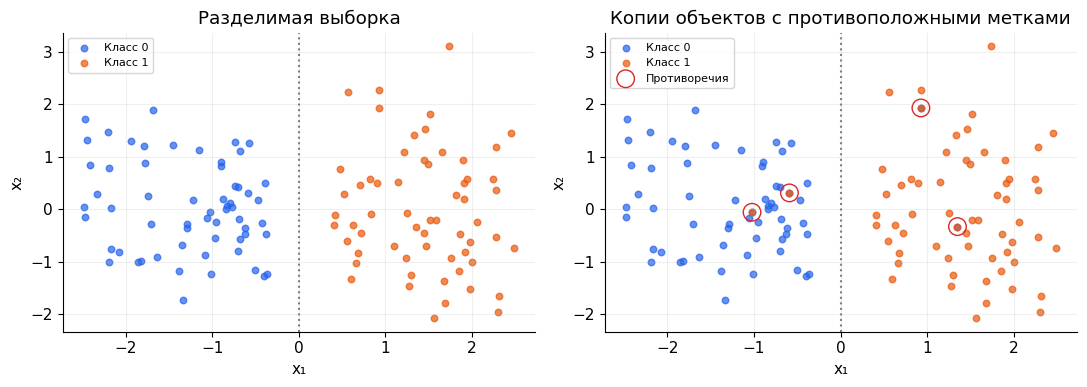

In [5]:
rng_sep=np.random.default_rng(103)
y_sep=np.repeat([0,1],60)
X_sep=np.c_[(2*y_sep-1)*rng_sep.uniform(.35,2.5,len(y_sep)),rng_sep.normal(size=len(y_sep))]
A_sep=np.c_[X_sep,np.zeros(len(X_sep))]  # b зафиксирован в нуле
conflicting_ids=np.array([0,15,60,75])
X_conflict=np.vstack([X_sep,X_sep[conflicting_ids]])
y_conflict=np.r_[y_sep,1-y_sep[conflicting_ids]]
A_conflict=np.c_[X_conflict,np.zeros(len(X_conflict))]
fig,axes=plt.subplots(1,2,figsize=(11,4))
class_scatter(axes[0],X_sep,y_sep);axes[0].set_title('Разделимая выборка')
class_scatter(axes[1],X_conflict,y_conflict);axes[1].set_title('Копии объектов с противоположными метками')
axes[1].scatter(X_sep[conflicting_ids,0],X_sep[conflicting_ids,1],s=160,facecolors='none',edgecolors=RED,label='Противоречия')
for ax in axes:ax.axvline(0,color='gray',ls=':');ax.legend(fontsize=8)
plt.tight_layout();plt.show()

### 2.2. Соберите три запуска
`trace_gd(A, y, loss_grad, lam, steps, lr)` — готовый полный градиентный спуск. Он сохраняет примерно 100 состояний, поэтому графики не перегружаются.

Соберите словарь из трёх историй с ключами `plain`, `ridge`, `conflict`. Для каждой используйте вашу `logistic_loss_grad`, 4000 шагов и шаг 0.5. В сценарии `ridge` задайте `lam=0.05`, в остальных — ноль. Для противоречивого сценария используйте `A_conflict, y_conflict`.

Смотрим отдельно на **log loss без штрафа** и на норму весов: иначе было бы неясно, за счёт какой части критерия меняется число на графике.

In [6]:
def trace_gd(A,y,loss_grad,lam=0.,steps=4000,lr=.5):
    theta=np.zeros(A.shape[1])
    checkpoints=set(np.unique(np.r_[0,np.geomspace(1,steps,100).astype(int)]))
    rows=[];weights=[]
    for t in range(steps+1):
        loss,g=loss_grad(A,y,theta,lam)
        if not np.isfinite(loss) or not np.isfinite(g).all():
            raise FloatingPointError('Потеря или градиент не конечны: проверьте реализацию и шаг')
        if t in checkpoints:
            z=A@theta
            rows.append({'step':t,'log_loss':float(np.mean(np.logaddexp(0,(1-2*y)*z))),
                         'accuracy':float(np.mean((z>=0)==y)),
                         'norm':float(np.linalg.norm(theta[:-1])), 'objective':loss})
            weights.append(theta.copy())
        if t<steps:theta=theta-lr*g
    return {'metrics':pd.DataFrame(rows),'weights':np.asarray(weights)}

In [7]:
def separability_experiment():
    # ВАШ КОД: три вызова trace_gd и словарь {'plain': ..., 'ridge': ..., 'conflict': ...}.
    raise NotImplementedError('Соберите три эксперимента в 2.2')

In [8]:
histories=None
try:
    histories=separability_experiment()
    assert set(histories)=={'plain','ridge','conflict'}
    fig,axes=plt.subplots(1,3,figsize=(14,4))
    for key,title,color in [('plain','Без штрафа',BLUE),('ridge','L2',GREEN),('conflict','Противоречия',RED)]:
        h=histories[key]['metrics']
        assert h.iloc[-1]['step']==4000
        for ax,metric in zip(axes,['accuracy','log_loss','norm']):
            ax.plot(h['step'],h[metric],label=title,color=color)
            ax.set_xscale('symlog',linthresh=10)
    for ax,title in zip(axes,['Accuracy','Log loss без штрафа','Норма весов']):
        ax.set(xlabel='Шаг GD (после 10 — лог. шкала)',title=title);ax.legend(fontsize=8)
    plt.tight_layout();plt.show()
    display(pd.DataFrame({k:v['metrics'].iloc[-1] for k,v in histories.items()}).T)
except NotImplementedError as e:
    print(e)

Соберите три эксперимента в 2.2


### 2.3. Сравните направление и зазор с SVM
Для $s_i=2y_i-1$ определим **геометрический отступ** объекта:
$$m_i=\frac{s_iw^\top x_i}{\|w\|},\qquad m_{min}=\min_i m_i.$$
Масштабирование $w$ не меняет границу и этот отступ. SVM максимального зазора без сдвига ищет $\min\|w\|^2/2$ при $s_iw^\top x_i\ge1$.

Для сопоставления используем `SVC(kernel='linear', C=10000)` на **зеркально дополненной** выборке $(x,s),(-x,-s)$. Ограничения дублируют исходные при $b=0$, а симметрия позволяет получить решение со сдвигом около нуля. Проверяем численно сдвиг и разделимость; большое `C` само по себе не доказывает hard-margin режим.

После запуска ответьте:

1. Растёт ли норма GD после достижения accuracy = 1?
2. Приближается ли направление GD к направлению SVM? Как меняется минимальный геометрический отступ?
3. Следует ли из конечного графика строгое доказательство асимптотического утверждения?

In [9]:
X_sym=np.vstack([X_sep,-X_sep]);y_sym=np.r_[y_sep,1-y_sep]
svm_sep=SVC(kernel='linear',C=10000,tol=1e-8).fit(X_sym,y_sym)
w_svm=svm_sep.coef_[0]
assert abs(svm_sep.intercept_[0])<1e-4
assert np.min((2*y_sep-1)*(X_sep@w_svm))>.999
margin_svm=np.min((2*y_sep-1)*(X_sep@w_svm))/np.linalg.norm(w_svm)
if histories is not None:
    ws=histories['plain']['weights'][1:,:-1]
    step=histories['plain']['metrics']['step'].to_numpy()[1:]
    lengths=np.linalg.norm(ws,axis=1)
    cosines=np.clip(ws@w_svm/(lengths*np.linalg.norm(w_svm)),-1,1)
    angles=np.degrees(np.arccos(cosines))
    margins=np.min((2*y_sep-1)[None,:]*(ws@X_sep.T),axis=1)/lengths
    fig,axes=plt.subplots(1,3,figsize=(14,4))
    axes[0].semilogx(step,angles);axes[0].set(xlabel='Шаг',ylabel='Угол, градусы',title='Направление GD относительно SVM')
    axes[1].semilogx(step,margins,label='GD')
    axes[1].axhline(margin_svm,color=GREEN,ls='--',label='SVM')
    axes[1].set(xlabel='Шаг',ylabel='Минимальный отступ',title='Зазор не зависит от нормы весов');axes[1].legend()
    class_scatter(axes[2],X_sep,y_sep)
    boundary(axes[2],histories['plain']['weights'][-1],colors=[BLUE])
    boundary(axes[2],np.r_[w_svm,0.],colors=[GREEN],linestyles='--')
    axes[2].set(title='Синяя: GD; зелёная пунктирная: SVM',xlim=(-3,3),ylim=(-3,3))
    plt.tight_layout();plt.show()
else:
    print('Графики GD появятся после задания 2.2; SVM уже обучен.')

Графики GD появятся после задания 2.2; SVM уже обучен.


### 2.4. Объясните наблюдение
На строго разделимой выборке существует направление $v$, для которого $s_iv^\top x_i>0$ для всех объектов. Рассмотрите веса $w=cv$ при $c\to\infty$:
$$\ell_i(cv)=\log\bigl(1+\exp(-c\,s_iv^\top x_i)\bigr).$$

**Допишите вывод:** к чему стремится потеря и достигается ли это значение при конечном $c$? Почему правильные метки не останавливают оптимизацию? …

**По вашим графикам:** как L2 и противоречивые наблюдения изменили поведение? …

**Расширение:** связь направления полного GD с максимальным зазором — асимптотический результат при определённых условиях, включая разделимость и подходящий шаг. Она не означает равенство двух алгоритмов после заданного числа итераций. В этом эксперименте сдвиг фиксирован в нуле, поэтому сравниваем одну геометрию нормы.

## 3. XOR: когда прямой недостаточно
### 3.1. Данные и гипотезы
Пусть $x_1,x_2$ независимо равномерны на $[-2,2]$, а метка задаётся исключающим ИЛИ:
$$y=\mathbf1\{(x_1>0)\ \mathrm{XOR}\ (x_2>0)\}.$$
Класс 1 занимает два противоположных квадранта. Метки детерминированы, шума нет: ошибки здесь связаны с моделью и конечной выборкой, а не с неоднозначностью ответа.

**Перед обучением:** объясните, почему одна прямая не разделяет четыре квадранта. Какие из моделей должны справиться: логистическая регрессия, линейный SVM, RBF-SVM, дерево, kNN? Достаточно ли дереву глубины 2 выразить правило XOR? Обязательно ли жадное обучение найдёт такое дерево?

Генерируем независимые train, validation и test. На графиках решений далее показаны только validation-объекты; test сохраняем до окончательного выбора модели.

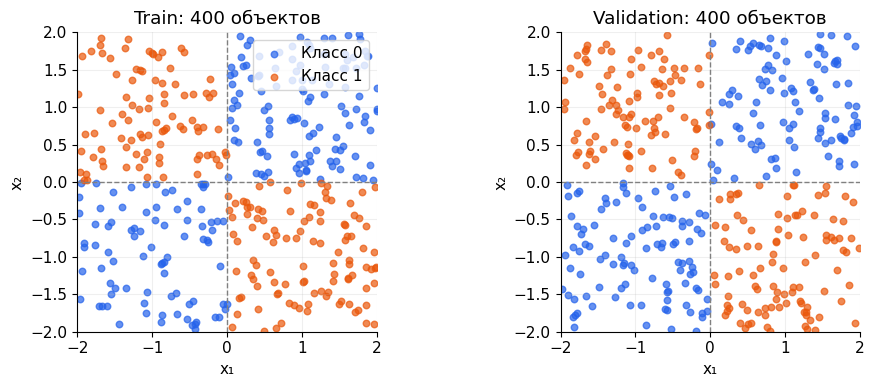

In [10]:
rng_xor = np.random.default_rng(2026)
def make_xor(n):
    X = rng_xor.uniform(-2, 2, size=(n, 2))
    y = ((X[:, 0] > 0) ^ (X[:, 1] > 0)).astype(int)
    return X, y

X_xor_train, y_xor_train = make_xor(400)
X_xor_val, y_xor_val = make_xor(400)
X_xor_test, y_xor_test = make_xor(2000)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, X, y, title in [(axes[0], X_xor_train, y_xor_train, 'Train: 400 объектов'),
                         (axes[1], X_xor_val, y_xor_val, 'Validation: 400 объектов')]:
    class_scatter(ax, X, y)
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.axvline(0, color='gray', ls='--', lw=1)
    ax.set(title=title, xlim=(-2,2), ylim=(-2,2), aspect='equal')
axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

### 3.2. Обучите пять классификаторов
Заполните `build_xor_models`: верните словарь из пяти **необученных** моделей с понятными названиями.

| Модель | Начальные параметры |
|---|---|
| Логистическая регрессия | `C=1`, `max_iter=2000` |
| Линейный SVM | `kernel="linear"`, `C=1` |
| RBF-SVM | `kernel="rbf"`, `C=10`, `gamma=1` |
| Дерево | `max_depth=4`, `random_state=SEED` |
| kNN | `n_neighbors=15` |

Для всех моделей кроме дерева используйте `make_pipeline(StandardScaler(), ...)`. Обучение и оценку выполняет готовая функция ниже. В таблице **Train accuracy** считается на train, остальные столбцы — на validation.

После начального запуска попробуйте глубину дерева 2 и 8, число соседей 1 и 51. Меняйте один параметр за раз. Сравнивайте train и validation, а также форму границы: одно число не объясняет, где модель ошибается.

In [11]:
def xor_metrics(model, X, y):
    pred = model.predict(X)
    score = (model.decision_function(X) if hasattr(model, 'decision_function')
             else model.predict_proba(X)[:, 1])
    return {'Accuracy': accuracy_score(y, pred),
            'F1': f1_score(y, pred, zero_division=0),
            'ROC AUC': roc_auc_score(y, score)}

def fit_xor_models(models):
    fitted = {name: clone(model).fit(X_xor_train, y_xor_train)
              for name, model in models.items()}
    rows = []
    for name, model in fitted.items():
        rows.append({'Модель': name,
                     'Train accuracy': accuracy_score(y_xor_train, model.predict(X_xor_train)),
                     **xor_metrics(model, X_xor_val, y_xor_val)})
    return fitted, pd.DataFrame(rows).set_index('Модель')

def plot_xor_models(models, X, y, truth_panel=True):
    # Общий масштаб, сетка и цветовая семантика для всех моделей.
    grid_axis = np.linspace(-2, 2, 220)
    xx, yy = np.meshgrid(grid_axis, grid_axis)
    grid = np.c_[xx.ravel(), yy.ravel()]
    panels = list(models.items()) + ([('Истинное правило XOR', None)] if truth_panel else [])
    ncols = 2 if len(panels) == 4 else min(3, len(panels))
    nrows = (len(panels) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4*ncols, 4.3*nrows), squeeze=False)
    cmap = ListedColormap(['#dbeafe', '#ffedd5'])
    for ax, (name, model) in zip(axes.flat, panels):
        region = ((grid[:, 0] > 0) ^ (grid[:, 1] > 0)).astype(int) if model is None else model.predict(grid)
        ax.contourf(xx, yy, region.reshape(xx.shape), levels=[-.5, .5, 1.5], cmap=cmap)
        if region.min() != region.max():
            ax.contour(xx, yy, region.reshape(xx.shape), levels=[.5], colors='#334155', linewidths=1.4)
        for label, color in [(0, BLUE), (1, ORANGE)]:
            mask = y == label
            ax.scatter(X[mask, 0], X[mask, 1], c=color, s=15, alpha=.7, edgecolors='white', linewidths=.25)
        if model is not None:
            wrong = model.predict(X) != y
            ax.scatter(X[wrong, 0], X[wrong, 1], s=44, facecolors='none', edgecolors=RED, linewidths=.9)
            scores = xor_metrics(model, X, y)
            subtitle = f"accuracy = {scores['Accuracy']:.3f} · F1 = {scores['F1']:.3f}"
        else:
            subtitle = 'Метки без шума'
        ax.axhline(0, color='#64748b', ls='--', lw=.8, alpha=.7)
        ax.axvline(0, color='#64748b', ls='--', lw=.8, alpha=.7)
        ax.set(xlim=(-2, 2), ylim=(-2, 2), xlabel='x₁', ylabel='x₂', title=name+'\n'+subtitle, aspect='equal')
        ax.grid(False)
    for ax in list(axes.flat)[len(panels):]:
        ax.set_visible(False)
    handles = [Line2D([], [], marker='o', ls='', color=c, label=f'Класс {k}') for k,c in [(0,BLUE),(1,ORANGE)]]
    handles.append(Line2D([], [], marker='o', ls='', markerfacecolor='none', color=RED, label='Ошибка на validation'))
    fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False)
    fig.tight_layout(rect=(0, .13 if nrows == 1 else .045, 1, 1))
    plt.show()

In [12]:
def build_xor_models():
    # ВАШ КОД: пять моделей; не вызывайте fit внутри этой функции.
    raise NotImplementedError('Соберите словарь классификаторов')

In [13]:
xor_models = None
try:
    candidates = build_xor_models()
    assert len(candidates) == 5, 'Ожидаем пять классификаторов'
    xor_models, xor_table = fit_xor_models(candidates)
except NotImplementedError as exc:
    print(exc)
if xor_models is not None:
    display(xor_table.round(3))
    plot_xor_models(xor_models, X_xor_val, y_xor_val)

Соберите словарь классификаторов


**Как читать рисунок.** Фон — предсказанный класс, а не уверенность модели. Цвет точки — её истинная метка. Красное кольцо обозначает ошибку на validation. Чёрная линия — граница модели, пунктирные оси — истинная граница XOR. Все панели используют одинаковый масштаб. Последняя показывает само правило генерации.

**Объясните:** какие ограничения видны у линейных моделей? Почему увеличение `C` не создаст у них нелинейную границу? Где ошибаются нелинейные модели: около осей, у края области или внутри квадрантов? …

### 3.3. Научите логистическую регрессию решать XOR
Нелинейную границу можно получить, сохранив алгоритм логистической регрессии, но изменив признаки. Вместо исходного $x$ подадим в модель вектор мономов $\phi(x)$:
$$p(y=1\mid x)=\sigma(w^\top\phi(x)+b).$$
Модель линейна по $\phi(x)$, но её граница в исходных координатах может быть нелинейной.

**Задание.** Реализуйте `build_polynomial_logreg(degree=2)`, возвращающую необученный pipeline:

1. `PolynomialFeatures(degree=degree, include_bias=False)`;
2. `StandardScaler()`;
3. `LogisticRegression(C=1, max_iter=2000)`.

Полиномиальные признаки строим **до** стандартизации, чтобы затем привести новые столбцы к сопоставимым масштабам. Отдельный столбец единиц не нужен: сдвиг уже есть в логистической регрессии. Все обучаемые преобразования подгоняются только по train внутри pipeline.

Перед запуском выпишите все признаки, которые появятся для двух исходных переменных при `degree=2`. Достаточно ли добавить только квадраты $x_1^2,x_2^2$? Какой признак должен изменить ситуацию принципиально?

Готовый код сравнит три варианта при одинаковом `C`: исходные признаки, исходные признаки вместе с квадратами **без произведения $x_1x_2$**, полный полином степени 2. Это позволяет проверить роль взаимодействия, а не только увеличение числа столбцов.

Здесь **взаимодействием признаков** называется их произведение $x_1x_2$: оно зависит от двух координат одновременно. Вариант «Добавлены квадраты, без x₁x₂» использует только $(x_1,x_2,x_1^2,x_2^2)$.

In [14]:
def build_polynomial_logreg(degree=2):
    # ВАШ КОД: преобразование признаков, стандартизация и классификатор.
    raise NotImplementedError('Соберите логистическую регрессию с полиномиальными признаками')

In [15]:
def add_squares_only(X):
    return np.c_[X, X**2]

polynomial_models = None
try:
    polynomial_pipeline = build_polynomial_logreg(degree=2)
    polynomial_candidates = {
        'Исходные признаки': make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=2000)),
        'Добавлены квадраты, без x₁x₂': make_pipeline(FunctionTransformer(add_squares_only),
                                             StandardScaler(), LogisticRegression(C=1, max_iter=2000)),
        'Полином степени 2': polynomial_pipeline,
    }
    polynomial_models, polynomial_table = fit_xor_models(polynomial_candidates)
except NotImplementedError as exc:
    print(exc)
if polynomial_models is not None:
    display(polynomial_table.round(3))
    plot_xor_models(polynomial_models, X_xor_val, y_xor_val, truth_panel=False)
    fitted_poly = polynomial_models['Полином степени 2']
    feature_names = fitted_poly.named_steps['polynomialfeatures'].get_feature_names_out(['x1', 'x2'])
    print('Признаки:', ', '.join(feature_names))
    display(pd.Series(fitted_poly.named_steps['logisticregression'].coef_[0],
                      index=feature_names, name='Вес после стандартизации').to_frame().round(3))

Соберите логистическую регрессию с полиномиальными признаками


**Разберите результат.** Цвета и кольца ошибок имеют тот же смысл, что и в предыдущем сравнении. Все три модели используют логистическую потерю; меняется только пространство признаков.

- Как изменились validation F1 и форма границы при добавлении полного полинома? …
- Почему добавление только квадратов, без произведения $x_1x_2$, не решает проблему XOR? Подумайте, меняются ли они при смене знака одной координаты. …
- Какой столбец получил наибольший по модулю вес? Сопоставьте его знак с правилом генерации метки. Коэффициенты относятся к **стандартизованным** столбцам. …
- Запишите уравнение идеальной разделяющей гиперплоскости в новом пространстве. Как выглядит та же граница в плоскости $(x_1,x_2)$? …
- Почему корректнее говорить «линейно неразделимы в исходных признаках», чем просто «линейно неразделимы»? …

Полиномиальное преобразование позволяет **выразить** точное правило, но обучение на конечной выборке с регуляризацией не обязано дать ровно нулевую ошибку. Для этой части достаточно степени 2: повышение степени не требуется.

### 3.4. Подберите сложность RBF-SVM
Зафиксируйте `C=10` и сравните `gamma` из `[0.03, 0.3, 3, 30]`. Заполните словарь `rbf_candidates`: ключ — подпись с `gamma`, значение — pipeline со стандартизацией и SVC.

После запуска выберите вариант **по validation F1**, при равенстве — меньший `gamma`. Сначала сформулируйте гипотезу о слишком малом и слишком большом `gamma`. Объясняйте наблюдаемые результаты, даже если на данной выборке переобучение слабее ожидаемого.

Выбор выполняется по неокруглённым значениям: близкие F1 могут выглядеть одинаково при округлении. Небольшое преимущество на одной validation-выборке ещё не доказывает устойчивого превосходства модели.

In [16]:
def build_rbf_candidates():
    # ВАШ КОД: четыре значения gamma в порядке возрастания.
    raise NotImplementedError('Соберите варианты RBF-SVM')

In [17]:
rbf_models = None
selected_xor_model = None
try:
    rbf_candidates = build_rbf_candidates()
    assert len(rbf_candidates) == 4
    rbf_models, rbf_table = fit_xor_models(rbf_candidates)
except NotImplementedError as exc:
    print(exc)
if rbf_models is not None:
    display(rbf_table.round(5))
    plot_xor_models(rbf_models, X_xor_val, y_xor_val, truth_panel=False)
    # idxmax выбирает первое максимальное значение; кандидаты упорядочены по gamma.
    selected_name = rbf_table['F1'].idxmax()
    selected_xor_model = rbf_models[selected_name]
    print('Выбор по validation F1:', selected_name)

Соберите варианты RBF-SVM


**Выводы:**

- Что изменилось в форме границы при росте `gamma`? …
- У какой модели наибольший разрыв между train и validation? …
- Чем способность класса моделей выразить XOR отличается от способности алгоритма обучения найти нужную модель? …

### 3.5. Финальная проверка
После фиксации гиперпараметров установите `EVALUATE_XOR_TEST = True`. Код оценит выбранный RBF-SVM и логистическую регрессию с полиномиальными признаками степени 2 на test. Здесь сохраняем веса, обученные на train, чтобы сравнить validation и test для одной и той же модели. Не подбирайте новые параметры по этому результату.

In [18]:
EVALUATE_XOR_TEST = False
if EVALUATE_XOR_TEST:
    final_models = {}
    if selected_xor_model is not None:
        final_models['Выбранный RBF-SVM'] = selected_xor_model
    if polynomial_models is not None:
        final_models['Логрег: полином степени 2'] = polynomial_models['Полином степени 2']
    if final_models:
        display(pd.DataFrame({name: xor_metrics(model, X_xor_test, y_xor_test)
                              for name, model in final_models.items()}).T.round(3))
    else:
        print('Сначала обучите модели в 3.3 или 3.4.')
else:
    print('Test сохранён до фиксации выбора.')

Test сохранён до фиксации выбора.


**Итог эксперимента:** какой классификатор вы выбрали бы для этой задачи и почему? Достаточно ли сравнения метрик, или геометрия границы тоже повлияла на решение? …